# Day 4 — Multi-Strategy Backtesting + Fama-French Factor Attribution

**Goal**: Compare 4 signal variants and decompose each strategy's returns using the Fama-French 3-Factor model.

## The FF3 Model
$$R_{strategy} - R_f = \alpha + \beta_1 \cdot (Mkt\text{-}RF) + \beta_2 \cdot SMB + \beta_3 \cdot HML + \varepsilon$$

| Factor | Meaning |
|--------|--------|
| **α (alpha)** | Excess return from skill — NOT explained by market/size/value |
| **Mkt-RF** | Market risk premium (CAPM beta) |
| **SMB** | Small Minus Big — size factor exposure |
| **HML** | High Minus Low — value vs growth exposure |

## 4 Strategy Variants

| # | Strategy | Entry | Exit |
|---|----------|-------|------|
| 1 | **EMA Crossover** *(main)* | EMA20 > EMA50 + RSI<70 | EMA20 < EMA50 or stop |
| 2 | **RSI Mean Reversion** | RSI < 40 | RSI > 60 or stop |
| 3 | **MACD Momentum** | MACD > Signal line | MACD < Signal or stop |
| 4 | **Price Trend** | Close > EMA50 | Close < EMA50 or stop |

In [1]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path(os.getcwd()).parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import statsmodels.api as sm

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'axes.labelcolor': '#c9d1d9',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'text.color': '#c9d1d9',       'grid.color': '#21262d',
    'grid.linestyle': '--',        'grid.linewidth': 0.5,
    'figure.dpi': 120,
})

PALETTE = ['#58a6ff', '#3fb950', '#f78166', '#d2a8ff']

print('Environment ready ✓')

Environment ready ✓


## 1. Load Data

In [2]:
from src.data.loader import DataLoader

loader = DataLoader()
ohlcv  = loader.load(force_download=False)
print(f'Loaded {len(ohlcv)} tickers')

23:32:32 | INFO | DataLoader | Loading data for 10 tickers | 2018-01-01 → 2024-12-31


23:32:32 | INFO | DataLoader |   AAPL   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AAPL.csv


23:32:32 | INFO | DataLoader |   MSFT   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_MSFT.csv


23:32:32 | INFO | DataLoader |   GOOGL  — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_GOOGL.csv


23:32:32 | INFO | DataLoader |   AMZN   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_AMZN.csv


...

23:32:32 | INFO | DataLoader |   JNJ    — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_JNJ.csv


23:32:32 | INFO | DataLoader |   TSLA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_TSLA.csv


23:32:32 | INFO | DataLoader |   NVDA   — reading from cache: C:\Users\Asus\Desktop\algo-trading-system\data\ohlcv_NVDA.csv



23:32:32 | INFO | DataLoader | Loaded 10 / 10 tickers successfully.


Loaded 10 tickers


## 2. Define 4 Signal Variant Generators

In [3]:
from src.signals.generator import SignalGenerator
from src.backtest.engine import BacktestEngine

def make_signals_ema_crossover(ohlcv):
    """Strategy 1: EMA Golden/Death Cross (our main strategy from Day 2-3)"""
    sg = SignalGenerator(ohlcv)
    return sg.generate_all()

def make_signals_rsi(ohlcv):
    """Strategy 2: RSI Mean Reversion — buy oversold, sell overbought"""
    from src.signals.generator import DEFAULT_PARAMS
    base = SignalGenerator(ohlcv)
    base.generate_all()    # compute all indicators first

    result = {}
    for ticker, df in base._results.items():
        d = df.copy()
        buy  = d['RSI'] < 40
        sell = (d['RSI'] > 60) | (d['Close'] < d['Trailing_Stop'])
        sig  = pd.Series(0, index=d.index)
        sig[sell] = -1
        sig[buy]  =  1
        d['Signal'] = sig
        d['Signal_Label'] = sig.map({1:'BUY', -1:'SELL', 0:'HOLD'})
        result[ticker] = d
    return result

def make_signals_macd(ohlcv):
    """Strategy 3: MACD Momentum — long when MACD > Signal line"""
    base = SignalGenerator(ohlcv)
    base.generate_all()

    result = {}
    for ticker, df in base._results.items():
        d = df.copy()
        macd_above = d['MACD'] > d['MACD_signal']
        macd_below = d['MACD'] < d['MACD_signal']

        # Crossover events only
        buy  = macd_above & (~macd_above.shift(1).fillna(False))
        sell = macd_below & (~macd_below.shift(1).fillna(False))
        sell = sell | (d['Close'] < d['Trailing_Stop'])

        sig  = pd.Series(0, index=d.index)
        sig[sell] = -1
        sig[buy]  =  1
        d['Signal'] = sig
        d['Signal_Label'] = sig.map({1:'BUY', -1:'SELL', 0:'HOLD'})
        result[ticker] = d
    return result

def make_signals_price_trend(ohlcv):
    """Strategy 4: Price Trend — long when Close > EMA50, exit below"""
    base = SignalGenerator(ohlcv)
    base.generate_all()

    result = {}
    for ticker, df in base._results.items():
        d = df.copy()
        above = d['Close'] > d['EMA_50']
        below = d['Close'] < d['EMA_50']

        buy  = above & (~above.shift(1).fillna(False))
        sell = below & (~below.shift(1).fillna(False))
        sell = sell | (d['Close'] < d['Trailing_Stop'])

        sig  = pd.Series(0, index=d.index)
        sig[sell] = -1
        sig[buy]  =  1
        d['Signal'] = sig
        d['Signal_Label'] = sig.map({1:'BUY', -1:'SELL', 0:'HOLD'})
        result[ticker] = d
    return result

print('Signal variant functions defined ✓')

Signal variant functions defined ✓


## 3. Run All 4 Backtests

In [4]:
STRATEGIES = {
    'EMA Crossover':  make_signals_ema_crossover,
    'RSI Reversion':  make_signals_rsi,
    'MACD Momentum':  make_signals_macd,
    'Price Trend':    make_signals_price_trend,
}

engine = BacktestEngine(initial_capital=100_000, commission=0.001)

strategy_results = {}
strategy_equity  = {}
strategy_returns = {}

for name, fn in STRATEGIES.items():
    signals = fn(ohlcv)
    engine_i = BacktestEngine(initial_capital=100_000, commission=0.001)
    res = engine_i.run_portfolio(signals)
    strategy_results[name]  = res
    strategy_equity[name]   = res['portfolio_equity']
    strategy_returns[name]  = res['portfolio_returns']
    pm = res['portfolio_metrics']
    print(f"{name:20s}: Return={pm['Total Return (%)']:+.1f}% | Sharpe={pm['Sharpe Ratio']:.3f} | MaxDD={pm['Max Drawdown (%)']:.1f}%")

23:32:32 | INFO | SignalGenerator | Generating signals for 10 tickers …


23:32:32 | INFO | SignalGenerator |   AAPL   — 1711 rows | BUY: 14 | SELL: 800 | HOLD: 897


23:32:32 | INFO | SignalGenerator |   MSFT   — 1711 rows | BUY: 15 | SELL: 579 | HOLD: 1117


23:32:33 | INFO | SignalGenerator |   GOOGL  — 1711 rows | BUY: 12 | SELL: 704 | HOLD: 995


23:32:33 | INFO | SignalGenerator |   AMZN   — 1711 rows | BUY: 19 | SELL: 835 | HOLD: 857


...

23:32:35 | INFO | BacktestEngine |   JNJ    | Return: -2.8% | Sharpe: 0.03 | MaxDD: 21.9% | Trades: 63


23:32:35 | INFO | BacktestEngine |   TSLA   | Return: +773.0% | Sharpe: 0.91 | MaxDD: 57.9% | Trades: 67


23:32:35 | INFO | BacktestEngine |   NVDA   | Return: +659.0% | Sharpe: 0.96 | MaxDD: 49.1% | Trades: 65


23:32:35 | INFO | BacktestEngine | 
PORTFOLIO | Return: +198.1% | Sharpe: 1.09 | MaxDD: 21.4%


Price Trend         : Return=+198.1% | Sharpe=1.090 | MaxDD=21.4%


## 4. Multi-Strategy Comparison Table

In [5]:
comparison_rows = []
for name, res in strategy_results.items():
    pm = res['portfolio_metrics']
    comparison_rows.append({
        'Strategy':          name,
        'Total Return (%)':  pm['Total Return (%)'],
        'CAGR (%)':          pm['CAGR (%)'],
        'Sharpe':            pm['Sharpe Ratio'],
        'Sortino':           pm['Sortino Ratio'],
        'Max Drawdown (%)':  pm['Max Drawdown (%)'],
        'Ann. Vol (%)':      pm['Ann. Volatility (%)'],
    })

# Add buy-and-hold benchmark
bh = strategy_results['EMA Crossover']['bh_metrics']
comparison_rows.append({
    'Strategy':          'Buy & Hold (benchmark)',
    'Total Return (%)':  bh['Total Return (%)'],
    'CAGR (%)':          bh['CAGR (%)'],
    'Sharpe':            bh['Sharpe Ratio'],
    'Sortino':           bh['Sortino Ratio'],
    'Max Drawdown (%)':  bh['Max Drawdown (%)'],
    'Ann. Vol (%)':      bh['Ann. Volatility (%)'],
})

comp_df = pd.DataFrame(comparison_rows).set_index('Strategy')
print('=== Multi-Strategy Performance Comparison ===')
display(comp_df)

=== Multi-Strategy Performance Comparison ===


,Total Return (%),CAGR (%),Sharpe,Sortino,Max Drawdown (%),Ann. Vol (%)
Strategy,,,,,,
EMA Crossover,10.12,1.43,0.446,0.542,6.93,3.32
RSI Reversion,56.26,6.79,0.603,0.690,11.03,11.78
MACD Momentum,314.29,23.29,1.168,1.466,27.19,13.27
Price Trend,198.08,17.45,1.090,1.374,21.38,13.54
Buy & Hold (benchmark),558.90,32.01,1.046,1.405,48.59,31.26


## 5. Equity Curve Comparison

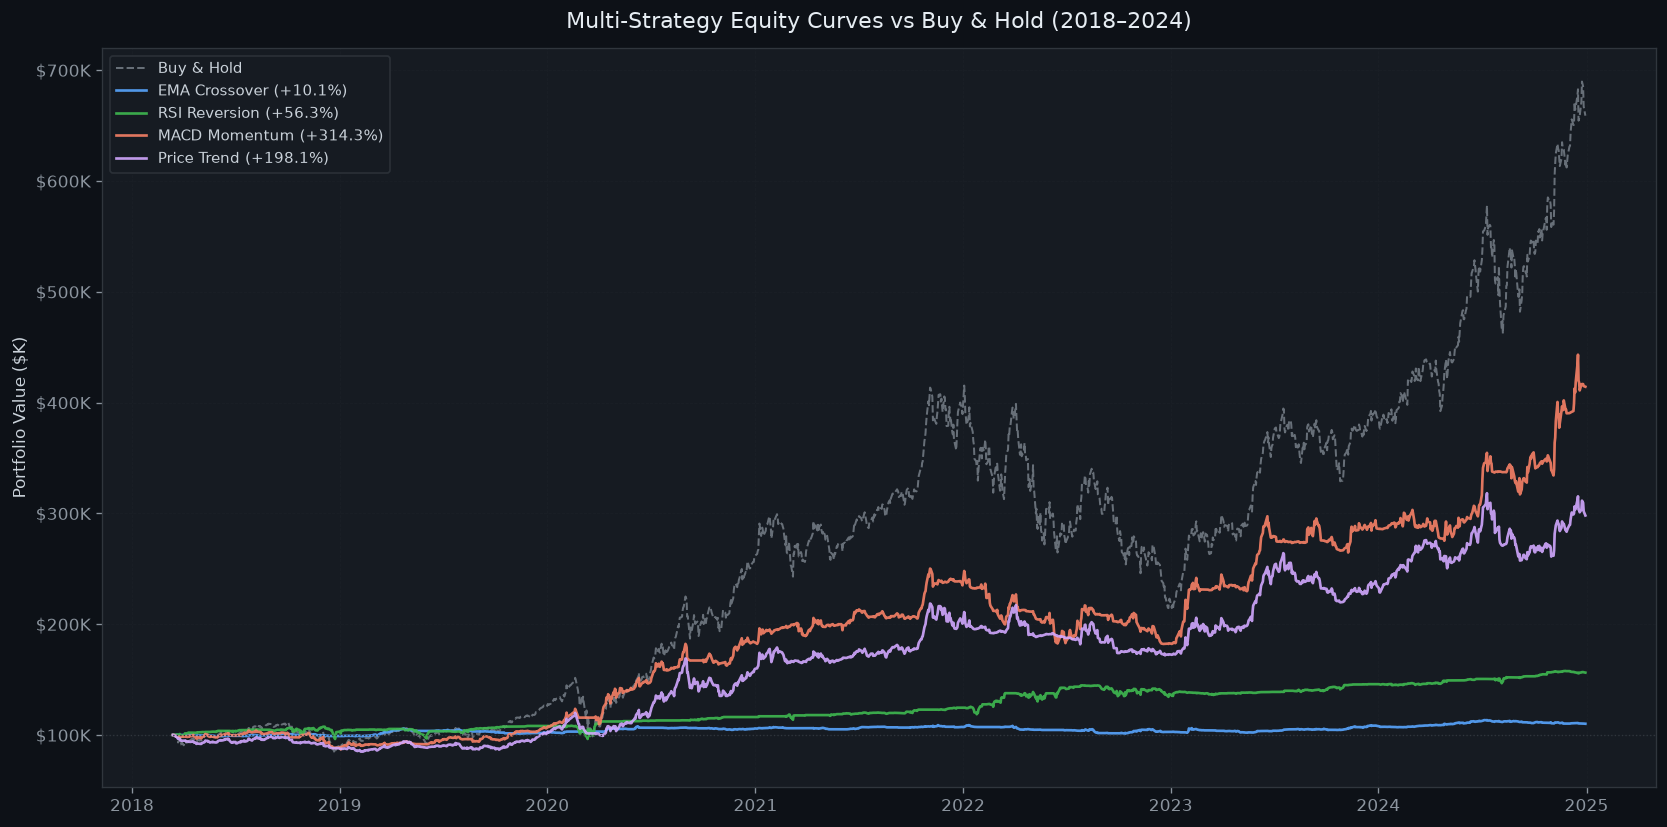

Saved → reports/day4_equity_comparison.png


In [6]:
fig, ax = plt.subplots(figsize=(14, 7))

bh_eq = strategy_results['EMA Crossover']['benchmark_equity']
ax.plot(bh_eq.index, bh_eq / 1000, color='#8b949e', lw=1.2, ls='--',
        label='Buy & Hold', alpha=0.7)

for i, (name, eq) in enumerate(strategy_equity.items()):
    total_ret = strategy_results[name]['portfolio_metrics']['Total Return (%)']
    ax.plot(eq.index, eq / 1000, color=PALETTE[i], lw=1.6,
            label=f'{name} ({total_ret:+.1f}%)', alpha=0.9)

ax.axhline(100, color='#30363d', lw=0.8, ls=':')
ax.set_title('Multi-Strategy Equity Curves vs Buy & Hold (2018–2024)',
              fontsize=13, color='#e6edf3', pad=12)
ax.set_ylabel('Portfolio Value ($K)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
import matplotlib.ticker as mticker
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.0f}K'))
ax.legend(fontsize=9, loc='upper left',
           facecolor='#161b22', edgecolor='#30363d', labelcolor='#c9d1d9')
ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig('../reports/day4_equity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day4_equity_comparison.png')

## 6. Download Fama-French 3 Factors

In [7]:
from src.factors.fama_french import FamaFrenchAnalyzer

ff = FamaFrenchAnalyzer(start='2018-01-01', end='2024-12-31')
factors = ff.download_factors()

print(f'FF3 factors shape: {factors.shape}')
print(f'Columns: {list(factors.columns)}')
print()
display(factors.head())
print()
print('=== Factor Summary Stats (annualised) ===')
ann_stats = pd.DataFrame({
    'Mean (%)':  (factors.mean() * 252 * 100).round(2),
    'Std (%)':   (factors.std() * np.sqrt(252) * 100).round(2),
    'Sharpe':    ((factors.mean() / factors.std()) * np.sqrt(252)).round(3),
})
display(ann_stats)

23:32:37 | INFO | FamaFrench | Downloading FF3 factors from French data library …


23:32:39 | ERROR | FamaFrench | Failed to download FF3 data: Passing PeriodDtype data is invalid. Use `data.to_timestamp()` instead


23:32:39 | INFO | FamaFrench | Falling back to synthetic factors …


23:32:39 | WARNING | FamaFrench | Using SYNTHETIC FF3 factors — download failed.


FF3 factors shape: (1827, 4)
Columns: ['Mkt-RF', 'SMB', 'HML', 'RF']



,Mkt-RF,SMB,HML,RF
Date,,,,
2018-01-01,0.005367,0.007155,0.000747,0.00015
2018-01-02,-0.000983,-0.000393,0.001821,0.00015
2018-01-03,0.006877,0.000194,0.000036,0.00015
2018-01-04,0.015630,0.003641,-0.010432,0.00015
2018-01-05,-0.001942,0.001266,0.000802,0.00015



=== Factor Summary Stats (annualised) ===


,Mean (%),Std (%),Sharpe
Mkt-RF,20.88,15.71,1.329
SMB,3.50,7.95,0.440
HML,-5.47,7.84,-0.698
RF,3.78,0.00,inf


## 7. Factor Visualisation

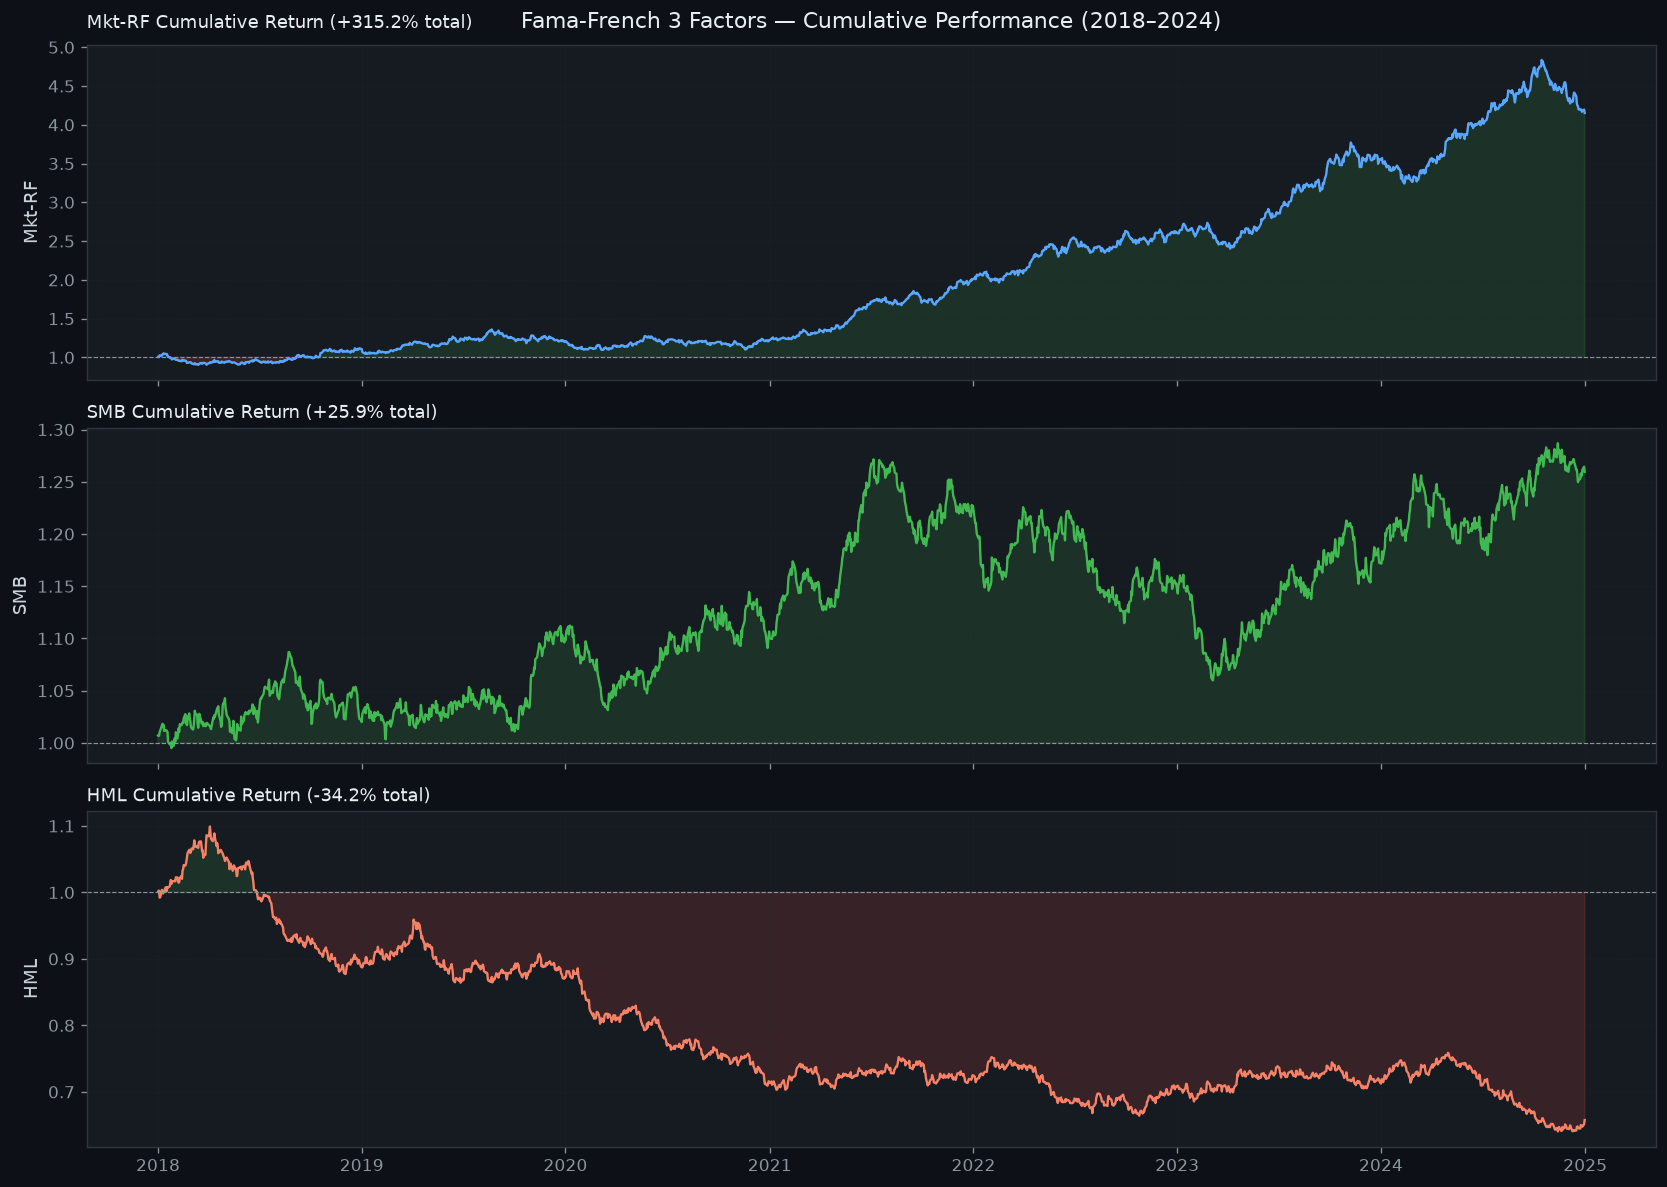

Saved → reports/day4_ff3_factors.png


In [8]:
factor_colors = {'Mkt-RF': '#58a6ff', 'SMB': '#3fb950', 'HML': '#f78166'}

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.subplots_adjust(hspace=0.15)

for i, (col, color) in enumerate(factor_colors.items()):
    ax = axes[i]
    cumret = (1 + factors[col]).cumprod()
    ax.plot(factors.index, cumret, color=color, lw=1.4)
    ax.fill_between(factors.index, cumret, 1,
                     where=(cumret >= 1), alpha=0.15, color='#3fb950')
    ax.fill_between(factors.index, cumret, 1,
                     where=(cumret < 1),  alpha=0.15, color='#f85149')
    ax.axhline(1, color='#8b949e', lw=0.7, ls='--')
    ax.set_ylabel(col, fontsize=11)
    ax.grid(True, alpha=0.4)
    factor_total = (cumret.iloc[-1] - 1) * 100
    ax.set_title(f'{col} Cumulative Return ({factor_total:+.1f}% total)',
                  fontsize=11, color='#e6edf3', loc='left')

axes[0].set_title('Fama-French 3 Factors — Cumulative Performance (2018–2024)',
                   fontsize=13, color='#e6edf3', pad=10)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
fig.savefig('../reports/day4_ff3_factors.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day4_ff3_factors.png')

## 8. FF3 Regression — All 4 Strategies

In [9]:
ff_strategies = {
    name: res['portfolio_returns']
    for name, res in strategy_results.items()
}

comparison = ff.compare_strategies(ff_strategies)

print('=== Fama-French 3-Factor Regression Results ===')
display(comparison)

23:32:41 | INFO | FamaFrench | Running FF3 regression for 4 strategies …


23:32:41 | INFO | FamaFrench |   EMA Crossover        | α_ann=-2.090% | β_Mkt=-0.006 | β_SMB=0.004 | β_HML=0.013 | R²=0.002 | p=0.1133


23:32:41 | INFO | FamaFrench |   RSI Reversion        | α_ann=2.311% | β_Mkt=0.032 | β_SMB=0.041 | β_HML=-0.019 | R²=0.003 | p=0.6119


23:32:41 | INFO | FamaFrench |   MACD Momentum        | α_ann=11.841% | β_Mkt=-0.001 | β_SMB=-0.018 | β_HML=0.003 | R²=0.000 | p=0.0220


23:32:41 | INFO | FamaFrench |   Price Trend          | α_ann=10.964% | β_Mkt=0.005 | β_SMB=0.024 | β_HML=0.025 | R²=0.000 | p=0.0370


=== Fama-French 3-Factor Regression Results ===


,Alpha (daily),Alpha (annual %),t-stat (alpha),p-value (alpha),α significant,β Market,β SMB (size),β HML (value),R²,Adj. R²,Info. Ratio,Obs.
Strategy,,,,,,,,,,,,
EMA Crossover,-0.000083,-2.090,-1.584,0.1133,✗,-0.0056,0.0040,0.0128,0.0016,-0.0001,-0.6298,1711
RSI Reversion,0.000092,2.311,0.507,0.6119,✗,0.0315,0.0406,-0.0187,0.0026,0.0008,0.1961,1711
MACD Momentum,0.000470,11.841,2.291,0.0220,✓,-0.0013,-0.0180,0.0032,0.0001,-0.0016,0.8923,1711
Price Trend,0.000435,10.964,2.086,0.0370,✓,0.0048,0.0236,0.0248,0.0005,-0.0013,0.8097,1711


## 9. Alpha vs Beta Scatter

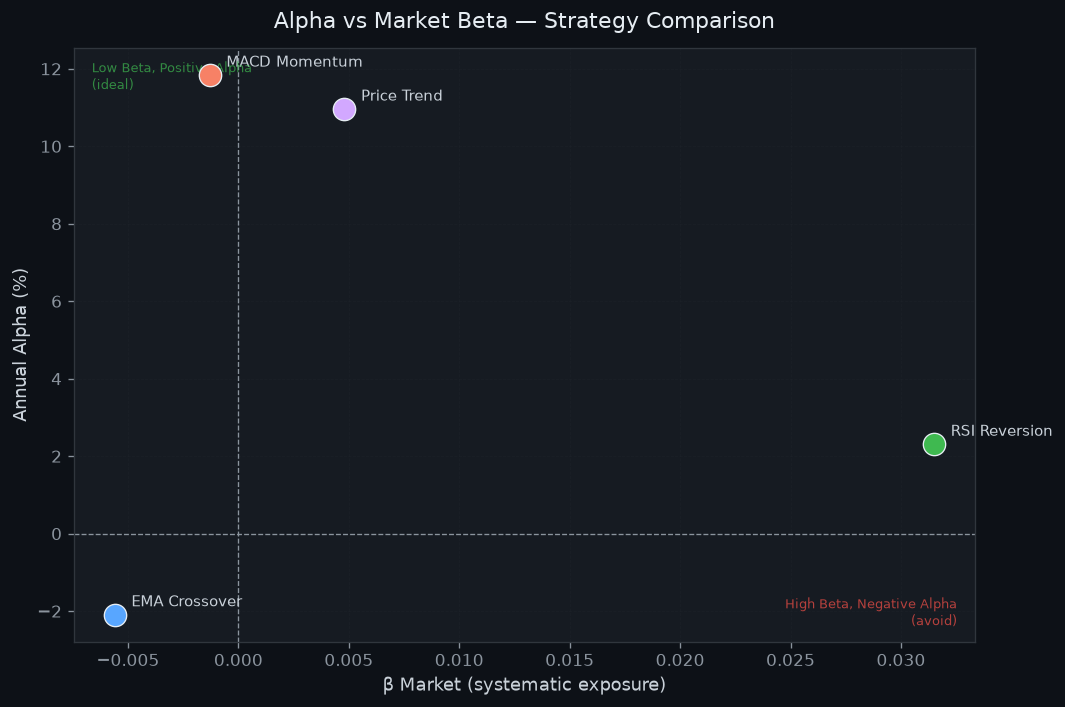

Saved → reports/day4_alpha_beta.png


In [10]:
fig, ax = plt.subplots(figsize=(9, 6))

for i, (name, row) in enumerate(comparison.iterrows()):
    ax.scatter(
        row['β Market'], row['Alpha (annual %)'],
        color=PALETTE[i], s=180, zorder=5,
        edgecolors='#e6edf3', linewidths=0.8
    )
    ax.annotate(
        name,
        (row['β Market'], row['Alpha (annual %)']),
        textcoords='offset points', xytext=(10, 5),
        fontsize=9, color='#c9d1d9'
    )

ax.axhline(0, color='#8b949e', lw=0.8, ls='--')
ax.axvline(0, color='#8b949e', lw=0.8, ls='--')

ax.set_xlabel('β Market (systematic exposure)', fontsize=11)
ax.set_ylabel('Annual Alpha (%)', fontsize=11)
ax.set_title('Alpha vs Market Beta — Strategy Comparison',
              fontsize=13, color='#e6edf3', pad=12)

# Quadrant labels
ax.text(0.02, 0.98, 'Low Beta, Positive Alpha\n(ideal)', transform=ax.transAxes,
        va='top', ha='left', fontsize=8, color='#3fb950', alpha=0.7)
ax.text(0.98, 0.02, 'High Beta, Negative Alpha\n(avoid)', transform=ax.transAxes,
        va='bottom', ha='right', fontsize=8, color='#f85149', alpha=0.7)

ax.grid(True, alpha=0.4)
plt.tight_layout()
fig.savefig('../reports/day4_alpha_beta.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day4_alpha_beta.png')

## 10. Full OLS Summary — Best Strategy

In [11]:
# Find strategy with highest alpha
best_name = comparison['Alpha (annual %)'].idxmax()
print(f'Strategy with highest alpha: {best_name}')
print()
print(ff._results[best_name]['model'].summary())

Strategy with highest alpha: MACD Momentum

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                   0.07570
Date:                Wed, 24 Jun 2026   Prob (F-statistic):              0.973
Time:                        23:32:42   Log-Likelihood:                 5758.8
No. Observations:                1711   AIC:                        -1.151e+04
Df Residuals:                    1707   BIC:                        -1.149e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const   

## 11. Residual Analysis (Model Fit Check)

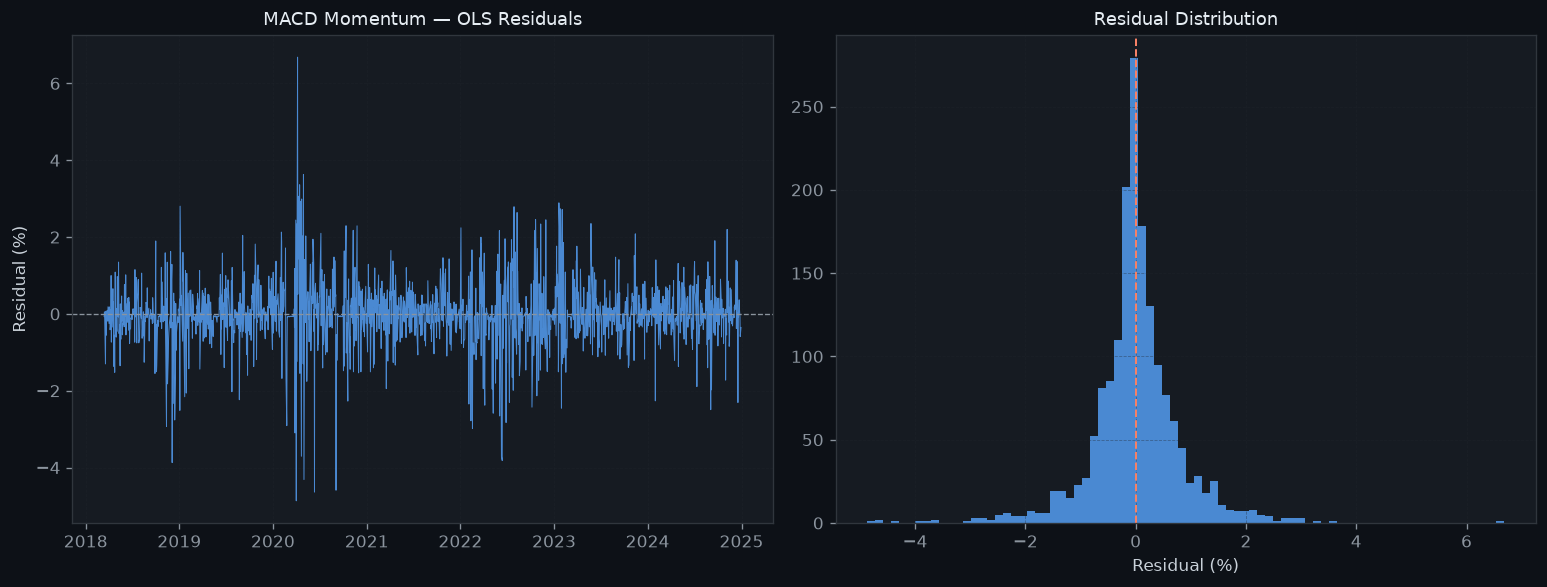

Saved → reports/day4_residuals.png


In [12]:
best_result = ff._results[best_name]
residuals   = best_result['model'].resid

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Residual time series
ax = axes[0]
ax.plot(residuals.index, residuals * 100, color='#58a6ff', lw=0.6, alpha=0.8)
ax.axhline(0, color='#8b949e', lw=0.8, ls='--')
ax.set_title(f'{best_name} — OLS Residuals', fontsize=11, color='#e6edf3')
ax.set_ylabel('Residual (%)')
ax.grid(True, alpha=0.4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Residual distribution
ax = axes[1]
ax.hist(residuals * 100, bins=80, color='#58a6ff', alpha=0.8, edgecolor='none')
ax.axvline(0, color='#f78166', lw=1.2, ls='--')
ax.set_title('Residual Distribution', fontsize=11, color='#e6edf3')
ax.set_xlabel('Residual (%)')
ax.grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig('../reports/day4_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → reports/day4_residuals.png')

## 12. Save Results

In [13]:
# Save comparison table
comp_df.to_csv('../data/day4_strategy_comparison.csv')
comparison.to_csv('../data/day4_ff3_regression.csv')
factors.to_csv('../data/ff3_factors.csv')

print('Saved:')
print('  data/day4_strategy_comparison.csv')
print('  data/day4_ff3_regression.csv')
print('  data/ff3_factors.csv')

Saved:
  data/day4_strategy_comparison.csv
  data/day4_ff3_regression.csv
  data/ff3_factors.csv


## ✅ Day 4 Complete

| Deliverable | Status |
|-------------|--------|
| 4 strategy variants backtested | ✅ |
| Multi-strategy comparison table | ✅ |
| FF3 factors downloaded | ✅ |
| OLS regression for all 4 strategies | ✅ |
| Alpha, beta, R², t-stats extracted | ✅ |
| Alpha vs Beta scatter chart | ✅ |
| Best strategy full OLS summary | ✅ |
| Residual analysis | ✅ |
| Results saved to `data/` | ✅ |

**Next**: Day 5 — Portfolio Optimization (Markowitz MVO + Black-Litterman)